##### This notebook's goal:
To complete and present exploratory data analysis, plotting, and other data mining insights from the Reddit joke dataset for this project.  Completed for INFO 523 (Data Mining) - Summer 2025. 

##### Author(s):
- (Ahn) Michael Howell - Human Language Technology Masters - Sociolinguist & Agentic AI Engineer - ahn@equita-tech.com
- Cat Xia

---

#### Gather imports

In [217]:
import ast # For ensuring preprocessed data is loaded as intended data types
import numpy as np
import pandas as pd
import seaborn as sns # For making plots
sns.set_theme(context = "notebook", style = "whitegrid")
import os # For saving plots
os.makedirs("./images", exist_ok = True)
import matplotlib.pyplot as plt

#### Create helper functions

In [218]:
### AHN

def show_df_details(df, details_to_include = []):
    if "head" in details_to_include:
        print(f"\n** HEAD:\n{df.head()}\n")
    if "tail" in details_to_include:
        print(f"\n** TAIL:\n{df.tail()}\n")
    if "info" in details_to_include:
        print(f"\n** INFO:\n")
        df.info()
        print(f"\n")
    if "describe" in details_to_include:
        print(f"\n** DESCRIBE:\n{df.describe()}\n")
    if "describe-all" in details_to_include:
        print(f"\n** DESCRIBE (ALL):\n{df.describe(include = 'all')}\n")

In [219]:
### CAT

#### Load preprocessed data

In [220]:
## LOAD DATA
preprocessed_df = pd.read_csv(
    "./data/preprocessed_dataset.csv",
    converters={"themes_found": ast.literal_eval})


# To verify our themes_found tuples (str, int) came in as intended:
print(f"\n** Verifying themes_found is tuples:\n")
total_themes = 0
for i, row in preprocessed_df.head(5).iterrows():
    print(f"@ {i}:")
    for theme, count in row["themes_found"]:
        print(f"\t{theme} ({count})")
        total_themes += count
print(f"\nFound {total_themes} themes in the first 5 rows\n")

## MERGE DATAFRAMES
jokes_df = preprocessed_df

## REVIEW DETAILS
show_df_details(jokes_df, ["dtypes", "head", "tail", "info", "describe"])


** Verifying themes_found is tuples:

@ 0:
	ethnicity (1)
@ 1:
	ethnicity (3)
@ 2:
	ethnicity (3)
@ 3:
	gender (1)
	class (1)
@ 4:
	class (2)
	age (1)

Found 12 themes in the first 5 rows


** HEAD:
       id  score  overall_length  distinct_words_count  theme_gender_count  \
0  5tz52q    1.0              22                     7                   0   
1  5tz4dd    0.0              27                    12                   0   
2  5tz319    0.0              40                    18                   0   
3  5tz2wj    1.0             105                    35                   1   
4  5tz1pc    0.0              30                    16                   0   

   theme_gender_bool  theme_ethnicity_count  theme_ethnicity_bool  \
0              False                      1                  True   
1              False                      3                  True   
2              False                      3                  True   
3               True                      0            

#### Additional data prep

In [221]:
### AHN

## STATIC GLOBALS
THEMES = ['gender','ethnicity','sexuality','ability','age','weight','appearance','class']
COUNT_COL_NAMES = [f"theme_{t}_count" for t in THEMES]

## HELPER FUNCTION
def make_long_df(df, min_count):
    long_df_list = []

    # For each theme, keep rows meeting threshold
    for theme in THEMES:
        included_rows = df[df[f"theme_{theme}_count"] >= min_count].copy()
        included_rows["theme"] = theme
        long_df_list.append(included_rows)

    # Handle rows with no themes (for this threshold)
    mask_any = (df[[f"theme_{t}_count" for t in THEMES]] >= min_count).any(axis = 1)
    none_rows = df[~mask_any].copy()
    none_rows["theme"] = "none"
    long_df_list.append(none_rows)

    # Put all together
    return pd.concat(long_df_list, ignore_index=True)


## GET THEME SETS (BUILD DATAFRAMES)
# Make melted dataframes, which have a "theme" column (rows with multiple themes are duplicated, per theme)
# This is our general dataframe for analysis - it introduces "theme" column for easy coloring, summing, averaging by theme
melted_default = make_long_df(jokes_df, min_count = 1)
# Insightful to have a set which is stricter, requiring at least a couple words to match a theme
melted_strict = make_long_df(jokes_df, min_count = 2)


# Example usage
print(f"\n** HEAD (default):\n{melted_default.head()}\n")
print(f"\n** HEAD (strict):\n{melted_strict.head()}\n")
print(f"\n** SAMPLE (default):\n{melted_default.sample(5, random_state = None)}\n")
print(f"\n** SAMPLE (strict):\n{melted_strict.sample(5, random_state = None)}\n")

# Gather theme sub-dfs easily
print(melted_strict[melted_strict["theme"] == "ethnicity"].head())

# Check everything is as expected
# 1 - melted row counts should not match original joke df; default should have more, strict should be fewer
print(f"\n** ROW COUNTS\nOriginal: {len(jokes_df)} | Melted (default): {len(melted_default)} | Melted (strict): {len(melted_strict)}\n")

# 2 - look at theme distributions briefly
print(f"\n** THEME DISTRIBUTION:\nDefault:\n{melted_default["theme"].value_counts()}\n\nStrict:\n{melted_strict["theme"].value_counts()}\n\n")

# 3 - each melted row should have one theme value (might be "none")
assert "theme" in melted_default.columns
assert melted_default["theme"].notna().all()


** HEAD (default):
       id  score  overall_length  distinct_words_count  theme_gender_count  \
0  5tz2wj    1.0             105                    35                   1   
1  5tz0ef    0.0              13                     9                   1   
2  5tyx6v    3.0             104                    37                  12   
3  5tyt6c    2.0              16                     7                   1   
4  5tyqag   62.0             249                    67                  15   

   theme_gender_bool  theme_ethnicity_count  theme_ethnicity_bool  \
0               True                      0                 False   
1               True                      0                 False   
2               True                      0                 False   
3               True                      0                 False   
4               True                      2                  True   

   theme_sexuality_count  theme_sexuality_bool  ...  theme_age_count  \
0                      0

In [222]:
### CAT

##### Exploratory data analysis (EDA)

In [223]:
### AHN

In [224]:
### CAT

##### Plotting & visual analysis

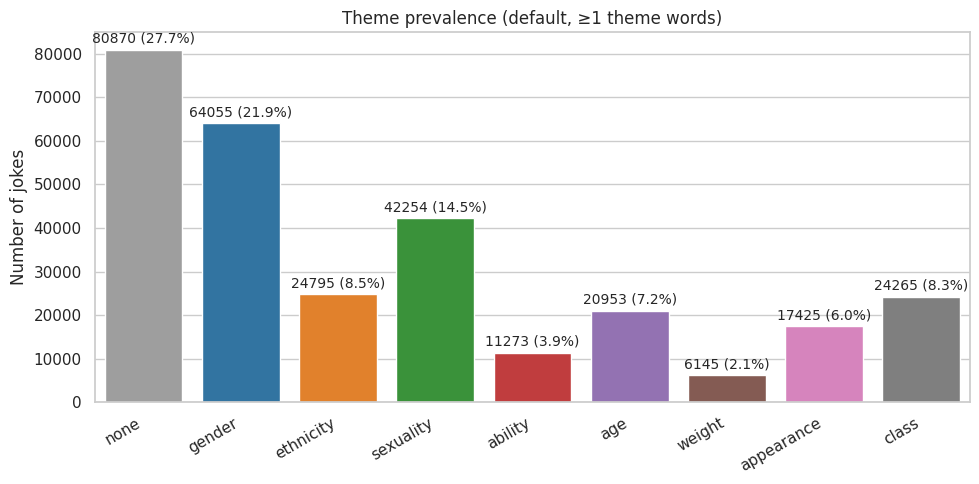

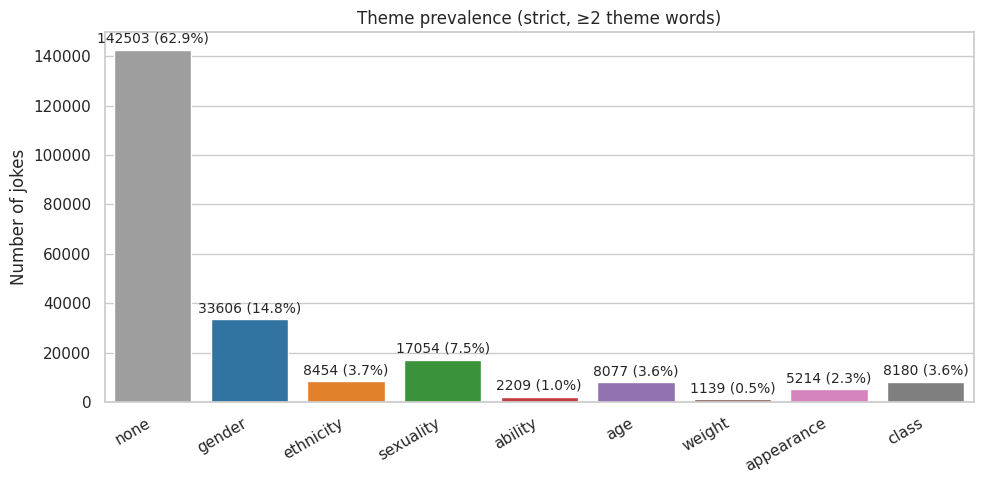

/tmp/ipykernel_6755/2559283715.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


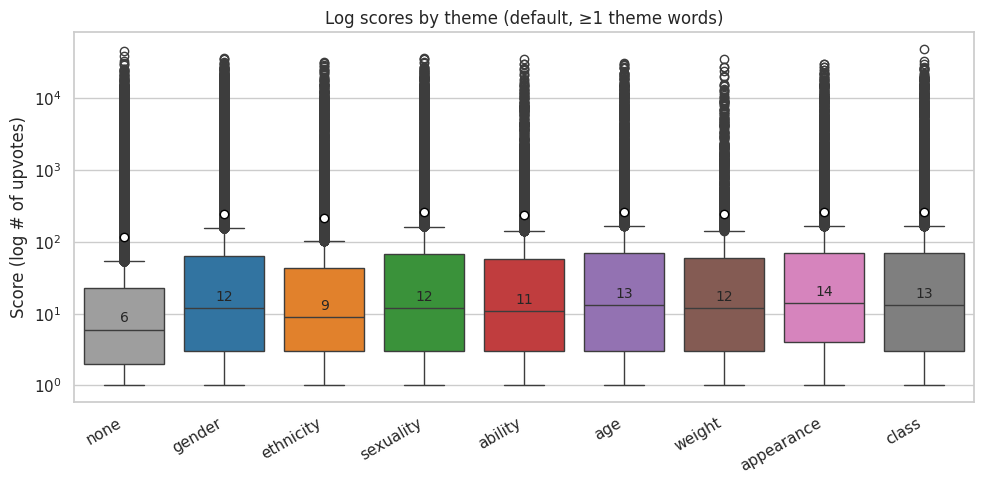

/tmp/ipykernel_6755/2559283715.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


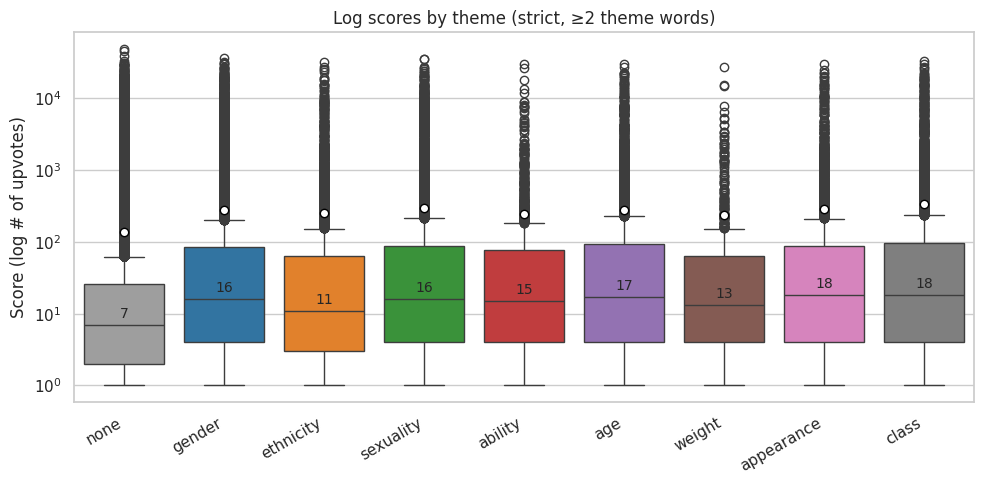

In [225]:
### AHN
# Each of these plots as default then as strict
# Use a fixed order and set of colors
THEME_ORDER = ['none', 'gender','ethnicity','sexuality','ability','age','weight','appearance','class']
THEME_PALETTE = {
    'none':       '#9e9e9e',  # gray
    'gender':     '#1f77b4',  # blue
    'ethnicity':  '#ff7f0e',  # orange
    'sexuality':  '#2ca02c',  # green
    'ability':    '#d62728',  # red
    'age':        '#9467bd',  # purple
    'weight':     '#8c564b',  # brown
    'appearance': '#e377c2',  # pink
    'class':      '#7f7f7f'   # dark gray
}

# 1 - Theme prevalence - bar plot
# > How common is each theme?

def plot_bar_theme_prevalence(melted, title, outpath):
    prev = (melted["theme"]
            .value_counts()
            .rename_axis("theme")
            .reset_index(name = "count"))

    # Reindex to ensure fixed order (including missing categories)
    prev = prev.set_index("theme").reindex(THEME_ORDER, fill_value = 0).reset_index()

    # Get the total count of jokes
    total = prev["count"].sum()

    plt.figure(figsize = (10, 5))
    ax = sns.barplot(
        data = prev,
        x = "theme", y = "count",
        order = THEME_ORDER,
        hue = "theme", hue_order = THEME_ORDER,
        palette = THEME_PALETTE,
        dodge = False
    )
    ax.set_title(title)
    ax.set_xlabel(""); ax.set_ylabel("Number of jokes")

    # Annotate each bar with its count and % of total jokes
    for p in ax.patches:
        count = int(p.get_height())
        percent = 100 * count / total if total > 0 else 0
        ax.annotate(f"{count} ({percent:.1f}%)",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'bottom',
                    xytext = (0, 3), textcoords = "offset points",
                    fontsize = 10)

    plt.xticks(rotation = 30, ha = "right")
    plt.tight_layout()
    plt.savefig(outpath, dpi = 150)
    plt.show()

plot_bar_theme_prevalence(
    melted_default,
    "Theme prevalence (default, ≥1 theme words)",
    "./images/ahn/bar_plot_theme_prevalence_default.png"
)

plot_bar_theme_prevalence(
    melted_strict,
    "Theme prevalence (strict, ≥2 theme words)",
    "./images/ahn/bar_plot_theme_prevalence_strict.png"
)

# 2 - Scores by theme - Violin plot (log?)
# > Which themes get higher or lower scores?

def plot_box_scores_by_theme(melted, title, outpath, log = True, stat = "median"):
    # Optional filtering for log scale; boxplot can't plot non-positive on log y
    df = melted.copy()
    if log:
        df = df[df["score"] > 0].copy()

    plt.figure(figsize = (10, 5))
    ax = sns.boxplot(
        data = df,
        x = "theme", y = "score",
        order = THEME_ORDER,
        palette = THEME_PALETTE,   # map colors by x
        showmeans = True,
        meanprops = {"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black"}
    )
    ax.set_title(title)
    ax.set_xlabel(""); ax.set_ylabel("Score (log # of upvotes)")

    if log:
        ax.set_yscale("log")

    # Add median annotation on box
    agg_fn = {"median": pd.Series.median, "mean": pd.Series.mean}.get(stat, pd.Series.median)
    grouped = (df.groupby("theme")["score"].apply(agg_fn)
                 .reindex(THEME_ORDER))  # Keep fixed order

    for i, theme in enumerate(THEME_ORDER):
        val = grouped.get(theme)
        if pd.isna(val):
            continue
        # Small pixel offset above the box (like bar labels)
        ax.annotate(f"{val:.0f}",
                    (i, val),
                    ha = 'center', va = 'bottom',
                    xytext = (0, 3), textcoords = "offset points",
                    fontsize = 10)

    plt.xticks(rotation = 30, ha = "right")
    plt.tight_layout()
    plt.savefig(outpath, dpi = 150)
    plt.show()

plot_box_scores_by_theme(
    melted_default,
    "Log scores by theme (default, ≥1 theme words)",
    "./images/ahn/box_plot_scores_default.png"
)

plot_box_scores_by_theme(
    melted_strict,
    "Log scores by theme (strict, ≥2 theme words)",
    "./images/ahn/box_plot_scores_strict.png"
)

# 3 - Scores vs number of themes - Box plot
# > Does a joke having more themes correlate with a higher score?

# 4 - Joke length vs. score, colored by theme - Scatter plot
# > Do longer jokes score differently than shorter ones (also showing theme trends)?

In [226]:
### CAT

##### Classification - model training & evaluation

In [227]:
### CAT

## Analysis Writeup
*Investigating Sociological & Marginalised Themes in Jokes*

Team: Ahn Michael, Cat Xia

This writeup presents our central questions, approach, and key findings from our Reddit joke data mining project.  Our primary goal was to study patterns between sociological categories (gender, race, ability, etc) and humor in jokes collected from Reddit around 2017, both in terms of distribution of the sociological themes as well as how they relate to user-assigned ratings. Our end project goal is to create a model that predicts the user rating of a joke based on the sociological categories it falls under as well as other linguistic features (joke length, distinct words used, etc).

**Content warning - problematic & vulgar language in the data:** this project explores sociopolitical themes and aims to accurately represent the way users interact with humor on Reddit, meaning that many of the jokes contain problematic, vulgar, or taboo topics and use of language; in order to accurately reflect this reality and our findings, we will minimally censor the data.

---

#### Our chosen dataset & questions

*The dataset*

We chose this dataset of 200,000+ jokes, collected by Taivo Pungas ([A dataset of English plaintext jokes](https://github.com/taivop/joke-dataset)), for the following reasons:

- It includes text data
  - We wanted to work with language-focused and social data, to be able to provide some sociological insights

- It provides an interesting perspective for analysing social questions
  - Humor (what a culture finds funny) often reflects important insights about what that culture sees as challenging, taboo, and uncomfortable.  Marginalised themes - such as talking about someone's weight or ability - are often at the center of what's being mocked or reflected on.

- It is complete
  - This dataset provides enough observations (rows) to be able to surface interesting trends, and the majority of those rows have complete information for their columns.

- It is available
  - Many of the other datasets we considered and found compelling are no longer available or have a high number of data protections making accessing them difficult, due to the sensitive themes of the data.



*The questions*

Our aim was to connect representation patterns (who/what gets joked about) with audience response (how those jokes are scored by users on Reddit).  We set out to answer the two following questions, with sub-questions of interest below:

**Q1: What are the differences in distributions among social categories, marginalised groups, or themes represented in the jokes?**
- Can we see any patterns around what types of jokes are most prominent?  
- Does the distribution suggest anything about the demographics of users on Reddit?  

**Q2: How does each social category/theme relate to the scores and rating - are certain themes rated more highly?**
- What are the distributions of scores per theme?
- Can we predict a joke’s rating based on its length and theme?
- Is there major influence from certain users who are more active than others?

While this dataset needed some augmentation and preprocessing to be most useful in answering our questions, it provided a great starting point with enough data points to surface trends.

---

#### Our initial observations

- The dataset of 200k+ jokes already had some helpful columns such as:
    - id (a unique identifier for each joke)
    - title (the joke's title text)
    - body (the joke's body text)
    - score (the number of upvotes Reddit users gave)

- We would need to augment the dataset with some engineered features, mainly regarding (a) measuring the themes in the jokes and (b) some helpful linguistic features: joke length, distinct words used, etc
- I (Ahn) was initially concerned that the jokes might be too generic and lack any overt indications of the themes I was interested in measuring - however, after reviewing some of the jokes, it was quickly apparent that not only were the themes present, but many presented in a very simple and vulgar form:
    - Example 1: TODO
    - Example 2: TODO

---

#### Our preprocessing & data prep

We selected to keep only Reddit jokes:
- The original dataset had jokes from 3 different sites, with this distribution: Reddit (~93.7%), StupidStuff (1.8%), and Wocka (4.8%)
- While the Reddit jokes had a score column (useful to our questions, measured as number of upvotes the joke received), the StupidStuff and Wocka sets either had no scores or scores using a different scale (0 to 5)
- This presented a number of challenges to comparing between the three, and due to the fact that these additional sites only composed around 6% of the total data, we chose to remove them and focus exclusively on Reddit jokes, leaving us with around 200,000 jokes to analyse

We normalised the texts and extracted important text features:

1. Combine all the joke text (title and body) into one string (whole_text)

    There may be interesting trends in what gets placed in the title vs. the body of a Reddit joke, but we decided to focus first on trends in the overall joke text

2. Applied lowercasing to the text

    This removed the influence of capitalising, ensuring that words with different casing would still be recognised as the same word, a common step in NLP/text normalisation

3. Removed non-letter characters

    This removes the influence of numbers, apostrophes, and unusual characters

4. Tokenised the joke, forming an array of contentful words

    This allowed us to calculate both the length of each joke (overall_length), as well as the array and number of distinct words used (distinct_words & distinct_words_count), potentially important features which may influence the scores users assign jokes: for example, perhaps shorter jokes with a more varied vocabulary would be rated higher by users

5. Removed stop words

    This helps our analysis focus on more meaningful content words ("beautiful", "gender", "work") more than structural/grammatical components ("is", "this", "and"); we used the ENGLISH_STOP_WORDS set from sklearn.feature_extraction.text



We also extracted 8 key sociological themes from the jokes, to identify the core sociopolitical themes present in the dataset:

- The themes are:
    - gender (concepts of gender binary performance, or lack thereof)
    - ethnicity (concepts of not only race, but some national identity & language groups)
    - sexuality (concepts around romance, sex, and sexuality)
    - ability (concepts around mental & physical ability, disability)
    - age
    - weight
    - appearance (concepts around beauty, desirability)
    - class (concepts around poverty, wealth, and labor)

- For each of these themes, we calculated both:
    - theme_<theme>_count, the number of words present in the joke relevant to this theme
    - theme_<theme>_bool, whether - useful for quicker comparisons

We calculated this by coming up with a predefined list of words for each theme, then checking across whole_text_normalised_tokens to see which themes were present.

- This data would be useful in two main ways:
    - We created a themes_found column/feature to help summarise quickly which themes were found in each joke - this column's value consists of an array of tuples (theme, word count), with themes sorted by word count, highest to lowest
        - Example: [('gender', 3), ('ability', 2)] would mean that in this joke, there were 3 words relevant to gender themes and 2 words relevant to ability, with gender sorted to be first (since it is the most present theme)
    - We would later create a theme column in a melted dataframe, allowing us to quickly group & analyse the jokes by the themes they contained





---

#### Our approach to analysis

- Created a theme column and melted the dataframes
- Created both default- and strict-theme dataframes
- Dataset & analysis limitations
    - Strict word-match interpretation of each theme

---

#### Our key findings - summary of analysis

- Plots & visual analysis
- Classification & model analysis

---

#### Our next steps & future directions

- Use an LLM to evaluate which themes are present in each joke
    - This would allow us to capture far more nuance about which themes are present but may not show up overtly in a single word; there are many jokes where the context or implication provides the sociological theme, not measurable by any individual word
    - Example: TODO

---